In [1]:
# Reading the cleaned numeric titanic survival data
import pandas as pd
import numpy as np


TitanicSurvivalDataNumeric=pd.read_pickle('TitanicSurvivalDataNumeric.pkl')
TitanicSurvivalDataNumeric.head(15)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1
5,0,3,1,44.5,0,0,8.4583,0,1,0
6,0,1,1,54.0,0,0,51.8625,0,0,1
7,0,3,1,2.0,3,1,21.0750,0,0,1
8,1,3,0,27.0,0,2,11.1333,0,0,1
9,1,2,0,14.0,1,0,30.0708,1,0,0


In [2]:
# Separate Target Variable and Predictor Variables
TargetVariable=['Survived']
Predictors=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked_C', 'Embarked_Q', 'Embarked_S']

X=TitanicSurvivalDataNumeric[Predictors].values
y=TitanicSurvivalDataNumeric[TargetVariable].values


### Sandardization of data ###
### We does not standardize the Target variable for classification
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()

# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X)

# Generating the standardized values of X and y
X=PredictorScalerFit.transform(X)
print(X)
# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Quick sanity check with the shapes of Training and Testing datasets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

[[ 0.82737724  0.73769513 -0.55604973 ... -0.4838099  -0.30974338
   0.61930636]
 [-1.56610693 -1.35557354  0.59548094 ...  2.06692751 -0.30974338
  -1.61470971]
 [ 0.82737724 -1.35557354 -0.26816707 ... -0.4838099  -0.30974338
   0.61930636]
 ...
 [ 0.82737724 -1.35557354 -0.5200644  ... -0.4838099  -0.30974338
   0.61930636]
 [-1.56610693  0.73769513 -0.26816707 ...  2.06692751 -0.30974338
  -1.61470971]
 [ 0.82737724  0.73769513  0.16365693 ... -0.4838099   3.22847904
  -1.61470971]]
(623, 9)
(623, 1)
(268, 9)
(268, 1)


In [3]:
#Build Artificial Neural Network
#Import the Keras libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense
classifier = Sequential()
# Defining the Input layer and FIRST hidden layer,both are same!
# relu means Rectifier linear unit function
classifier.add(Dense(units=10, input_dim=9, kernel_initializer='uniform', activation='relu'))

#Defining the SECOND hidden layer, here we have not defined input because it is
# second layer and it will get input as the output of first hidden layer
classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))

# Defining the Output layer
# sigmoid means sigmoid activation function
# for Multiclass classification the activation ='softmax'
# And output_dim will be equal to the number of factor levels
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))



2026-07-14 14:52:05.798643: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-14 14:52:05.918615: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-14 14:52:05.918652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-14 14:52:05.926199: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-14 14:52:05.962328: I tensorflow/core/platform/cpu_feature_guar

In [4]:
classifier.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                100       
                                                                 
 dense_1 (Dense)             (None, 6)                 66        
                                                                 
 dense_2 (Dense)             (None, 1)                 7         
                                                                 
Total params: 173 (692.00 Byte)
Trainable params: 173 (692.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
# Optimizer== the algorithm of SGG to keep updating weights
# loss== the loss function to measure the accuracy
# metrics== the way we will compare the accuracy after each step of SGD
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
# fitting the Neural Network on the training data
survivalANN_Model=classifier.fit(X_train,y_train, batch_size=10 , epochs=10, verbose=1)

Epoch 1/10


2026-07-14 14:52:08.334327: I external/local_xla/xla/service/service.cc:168] XLA service 0x781bf405bd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-14 14:52:08.334359: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-07-14 14:52:08.341413: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-14 14:52:08.358408: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1784020928.399642   53455 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 [==============================] - 1s 3ms/step - loss: 0.6880 - accuracy: 0.6292
Epoch 2/10
63/63 [==============================] - 0s 2ms/step - loss: 0.6531 - accuracy: 0.6581
Epoch 3/10
63/63 [==============================] - 0s 4ms/step - loss: 0.5756 - accuracy: 0.7512
Epoch 4/10
63/63 [==============================] - 0s 3ms/step - loss: 0.5135 - accuracy: 0.7994
Epoch 5/10
63/63 [==============================] - 0s 2ms/step - loss: 0.4816 - accuracy: 0.8010
Epoch 6/10
63/63 [==============================] - 0s 2ms/step - loss: 0.4648 - accuracy: 0.8058
Epoch 7/10
63/63 [==============================] - 0s 2ms/step - loss: 0.4558 - accuracy: 0.8042
Epoch 8/10
63/63 [==============================] - 0s 1ms/step - loss: 0.4504 - accuracy: 0.8074
Epoch 9/10
63/63 [==============================] - 0s 1ms/step - loss: 0.4467 - accuracy: 0.8090
Epoch 10/10
63/63 [==============================] - 0s 1ms/step - loss: 0.4427 - accuracy: 0.8090


In [7]:
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense

# Defining a function for finding best hyperparameters
def FunctionFindBestParams(X_train, y_train):

    # Defining the list of hyper parameters to try
    TrialNumber=0
    batch_size_list=[5, 10, 15, 20]
    epoch_list=[5, 10, 50 ,100]

    SearchResultsData=pd.DataFrame(columns=['TrialNumber', 'Parameters', 'Accuracy'])

    for batch_size_trial in batch_size_list:
        for epochs_trial in epoch_list:
            TrialNumber+=1

            # Creating the classifier ANN model
            classifier = Sequential()
            classifier.add(Dense(units=10, input_dim=9, kernel_initializer='uniform', activation='relu'))
            classifier.add(Dense(units=6, kernel_initializer='uniform', activation='relu'))
            classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))
            classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


            survivalANN_Model=classifier.fit(X_train,y_train, batch_size=batch_size_trial , epochs=epochs_trial, verbose=0)
            # Fetching the accuracy of the training
            Accuracy = survivalANN_Model.history['accuracy'][-1]

            # printing the results of the current iteration
            print(TrialNumber, 'Parameters:','batch_size:', batch_size_trial,'-', 'epochs:',epochs_trial, 'Accuracy:', Accuracy)

            # Use pd.concat instead of append
            SearchResultsData=pd.concat([SearchResultsData, pd.DataFrame(data=[[TrialNumber,
                            'batch_size'+str(batch_size_trial)+'-'+'epoch'+str(epochs_trial), Accuracy]],
                                                                    columns=['TrialNumber', 'Parameters', 'Accuracy'] )])
    return(SearchResultsData)

###############################################

# Calling the function
ResultsData=FunctionFindBestParams(X_train, y_train)

1 Parameters: batch_size: 5 - epochs: 5 Accuracy: 0.8105939030647278


/tmp/ipykernel_53347/298669683.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SearchResultsData=pd.concat([SearchResultsData, pd.DataFrame(data=[[TrialNumber,


2 Parameters: batch_size: 5 - epochs: 10 Accuracy: 0.8105939030647278
3 Parameters: batch_size: 5 - epochs: 50 Accuracy: 0.8523274660110474
4 Parameters: batch_size: 5 - epochs: 100 Accuracy: 0.8459069132804871
5 Parameters: batch_size: 10 - epochs: 5 Accuracy: 0.7929373979568481
6 Parameters: batch_size: 10 - epochs: 10 Accuracy: 0.8089887499809265
7 Parameters: batch_size: 10 - epochs: 50 Accuracy: 0.841091513633728
8 Parameters: batch_size: 10 - epochs: 100 Accuracy: 0.8459069132804871
9 Parameters: batch_size: 15 - epochs: 5 Accuracy: 0.7800962924957275
10 Parameters: batch_size: 15 - epochs: 10 Accuracy: 0.8154093027114868
11 Parameters: batch_size: 15 - epochs: 50 Accuracy: 0.8314606547355652
12 Parameters: batch_size: 15 - epochs: 100 Accuracy: 0.8491171598434448
13 Parameters: batch_size: 20 - epochs: 5 Accuracy: 0.7447832822799683
14 Parameters: batch_size: 20 - epochs: 10 Accuracy: 0.812199056148529
15 Parameters: batch_size: 20 - epochs: 50 Accuracy: 0.8266452550888062
16 Pa

  TrialNumber           Parameters  Accuracy
0           3  batch_size5-epoch50  0.852327


<Axes: xlabel='Parameters'>

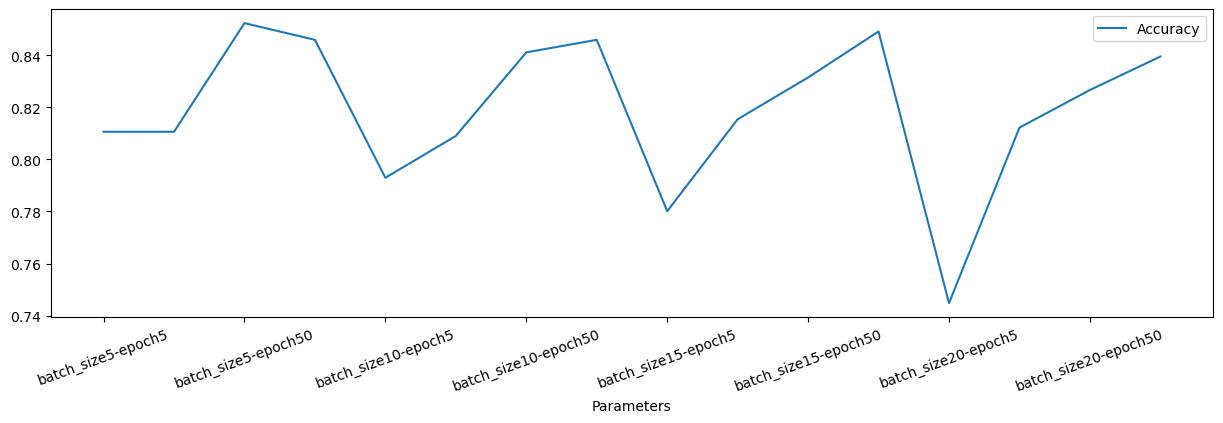

In [8]:
# Printing the best parameter
print(ResultsData.sort_values(by='Accuracy', ascending=False).head(1))

# Visualizing the results
%matplotlib inline
ResultsData.plot(x='Parameters', y='Accuracy', figsize=(15,4), kind='line', rot=20)

In [9]:
# Training the model with best hyperparamters
classifier.fit(X_train,y_train, batch_size=5 , epochs=100, verbose=1)

Epoch 1/100
125/125 [==============================] - 1s 5ms/step - loss: 0.4423 - accuracy: 0.8058
Epoch 2/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4393 - accuracy: 0.8122
Epoch 3/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4354 - accuracy: 0.8154
Epoch 4/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4322 - accuracy: 0.8122
Epoch 5/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4313 - accuracy: 0.8106
Epoch 6/100
125/125 [==============================] - 0s 2ms/step - loss: 0.4290 - accuracy: 0.8154
Epoch 7/100
125/125 [==============================] - 0s 4ms/step - loss: 0.4263 - accuracy: 0.8170
Epoch 8/100
125/125 [==============================] - 0s 3ms/step - loss: 0.4262 - accuracy: 0.8122
Epoch 9/100
125/125 [==============================] - 1s 5ms/step - loss: 0.4229 - accuracy: 0.8138
Epoch 10/100
125/125 [==============================] - 1s 5ms/step - loss: 0.4209 - accura

In [10]:
# Predictions on testing data
Predictions=classifier.predict(X_test)

# Scaling the test data back to original scale
Test_Data=PredictorScalerFit.inverse_transform(X_test)

# Generating a data frame for analyzing the test data
TestingData=pd.DataFrame(data=Test_Data, columns=Predictors)
TestingData['Survival']=y_test
TestingData['PredictedSurvivalProb']=Predictions

# Defining the probability threshold
def probThreshold(inpProb):
    if inpProb  >  0.5:
        return(1)
    else:
        return(0)

# Generating predictions on the testing data by applying probability threshold
TestingData['PredictedSurvival']=TestingData['PredictedSurvivalProb'].apply(probThreshold)
print(TestingData.head(5))

###############################################
from sklearn import metrics
print('\n######### Testing Accuracy Results #########')
print(metrics.classification_report(TestingData['Survival'], TestingData['PredictedSurvival']))
print(metrics.confusion_matrix(TestingData['Survival'], TestingData['PredictedSurvival']))

9/9 [==============================] - 0s 703us/step
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0     3.0  1.0  23.0    1.0    1.0  15.2458         1.0         0.0   
1     2.0  1.0  31.0    0.0    0.0  10.5000         0.0         0.0   
2     3.0  1.0  20.0    0.0    0.0   7.9250         0.0         0.0   
3     2.0  0.0   6.0    0.0    1.0  33.0000         0.0         0.0   
4     3.0  0.0  14.0    1.0    0.0  11.2417         1.0         0.0   

   Embarked_S  Survival  PredictedSurvivalProb  PredictedSurvival  
0         0.0         1               0.352309                  0  
1         1.0         0               0.091348                  0  
2         1.0         0               0.143081                  0  
3         1.0         1               0.954434                  1  
4         0.0         1               0.488898                  0  

######### Testing Accuracy Results #########
              precision    recall  f1-score   support

           

In [11]:
# Function to generate Deep ANN model
def make_classification_ann(Optimizer_Trial, Neurons_Trial):
    from keras.models import Sequential
    from keras.layers import Dense

    # Creating the classifier ANN model
    classifier = Sequential()
    classifier.add(Dense(units=Neurons_Trial, input_dim=9, kernel_initializer='uniform', activation='relu'))
    classifier.add(Dense(units=Neurons_Trial, kernel_initializer='uniform', activation='relu'))
    classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))
    classifier.compile(optimizer=Optimizer_Trial, loss='binary_crossentropy', metrics=['accuracy'])

    return classifier

########################################

from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier


Parameter_Trials={'batch_size':[10,20,30],
                      'epochs':[10,20],
                    'Optimizer_Trial':['adam', 'rmsprop'],
                  'Neurons_Trial': [5,10]
                 }

# Creating the classifier ANN
classifierModel=KerasClassifier(make_classification_ann, verbose=0)

########################################

# Creating the Grid search space
# See different scoring methods by using sklearn.metrics.SCORERS.keys()
grid_search=GridSearchCV(estimator=classifierModel, param_grid=Parameter_Trials, scoring='f1', cv=5)

########################################

# Measuring how much time it took to find the best params
import time
StartTime=time.time()

# Running Grid Search for different paramenters
grid_search.fit(X_train,y_train, verbose=1)

EndTime=time.time()
print("############### Total Time Taken: ", round((EndTime-StartTime)/60), 'Minutes #############')

########################################

# printing the best parameters
print('\n#### Best hyperparamters ####')
grid_search.best_params_

ModuleNotFoundError: No module named 'keras.wrappers'